In [2]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import hls4ml
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects
from hls4ml.model.profiling import numerical
import yaml
import os

2026-08-16 14:19:07.326459: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-16 14:19:07.343733: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-16 14:19:07.462796: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-16 14:19:07.463739: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-16 14:19:07.951120: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

In [3]:
data = sio.loadmat('data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

In [8]:
co = {}
_add_supported_quantized_objects(co)

q_model = load_model(
    "models/results/t1/8bits/best/model.h5",
    custom_objects=co
)

for layer in q_model.layers:
    print(layer.name)

q_conv2d
batch_normalization
q_activation
q_conv2d_1
batch_normalization_1
q_activation_1
flatten
q_dense
batch_normalization_2
q_activation_2
q_dense_1


/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [9]:
def build_hls_config(model: tf.keras.Model, reuse_factor: int = 1) -> dict:
    config = hls4ml.utils.config_from_keras_model(
        model,
        granularity="name",
        default_precision="ap_fixed<8,1>",
    )

    config["Model"]["Strategy"] = "Latency"
    config["Model"]["ReuseFactor"] = reuse_factor

    for layer_cfg in config["LayerName"].values():
        layer_cfg["Trace"] = True

    return config

def widen_accumulators(config: dict, accum_precision: str = "ap_int<24>") -> dict:
    for layer_name, layer_cfg in config["LayerName"].items():
        if "Precision" in layer_cfg and "accum" in layer_cfg["Precision"]:
            layer_cfg["Precision"]["accum"] = accum_precision
    return config


def generate_yaml(bits: int, experiment: str = "t1"):
    model_path = f"models/results/{experiment}/{bits}bits/best/model.h5"
    model = tf.keras.models.load_model(model_path, custom_objects=co)

    hls_config = build_hls_config(model, reuse_factor=1)
    hls_config = widen_accumulators(hls_config, accum_precision="ap_int<24>")

    config = {
        "ModelName": f"{experiment}_best_{bits}b",
        "Backend": "Vitis",
        "OutputDir": f"outputs/{experiment}/{bits}bits",
        "ProjectName": f"{experiment}_best_{bits}b",
        "KerasH5": model_path,
        "InputData": f"data/hls/{experiment}/{bits}bits/input_features.dat",
        "OutputPredictions": f"data/hls/{experiment}/{bits}bits/output_predictions.dat",
        "Part": "xc7z020clg400-1",
        "ClockPeriod": 10,
        "IOType": "io_stream",
        "HLSConfig": hls_config,
    }

    yaml_path = f"configs/{experiment}_{bits}b.yaml"
    os.makedirs("configs", exist_ok=True)
    with open(yaml_path, "w") as f:
        yaml.dump(config, f, sort_keys=False)

    print(f"Config gerada: {yaml_path}")

In [21]:
#for bits in [8, 4, 2, 1]:
#    generate_yaml(bits)

In [12]:
config_path = "configs/t1_8b.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
    

hls_model = hls4ml.converters.convert_from_keras_model(
    q_model,
    hls_config=config["HLSConfig"],
    output_dir=config["OutputDir"],
    backend=config["Backend"],
    part=config["Part"],
    clock_period=config["ClockPeriod"],
    io_type=config["IOType"],
    project_name=config["ProjectName"],
)

Profiling weights (before optimization)
Weights for q_conv2d are only zeros, ignoring.
Weights for q_conv2d_1 are only zeros, ignoring.
Weights for q_dense are only zeros, ignoring.
Weights for q_dense_1 are only zeros, ignoring.
[{'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'q_conv2d', 'weight': 'q_conv2d/w'}, {'med': 1.8787235, 'q1': 1.4411499202251434, 'q3': 2.8512020111083984, 'whislo': 0.95532393, 'whishi': 4.642146, 'layer': 'batch_normalization', 'weight': 'batch_normalization/w'}, {'med': 1.5855598, 'q1': 0.9762490689754486, 'q3': 2.0708855390548706, 'whislo': 0.018895954, 'whishi': 3.0026364, 'layer': 'batch_normalization', 'weight': 'batch_normalization/b'}, {'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'q_conv2d_1', 'weight': 'q_conv2d_1/w'}, {'med': 0.40073115, 'q1': 0.3116987869143486, 'q3': 0.48172924667596817, 'whislo': 0.15345843, 'whishi': 1.0995948, 'layer': 'batch_normalization_1', 'weight': 'batch_normalizatio

RuntimeError: ModelGraph must have tracing on for at least 1 layer (this can be set in its config)

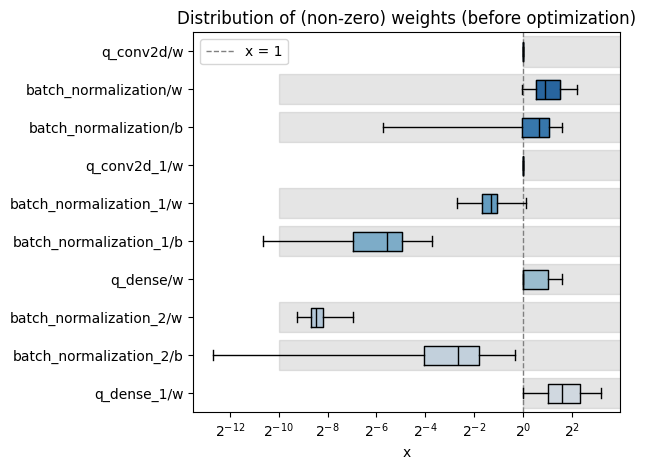

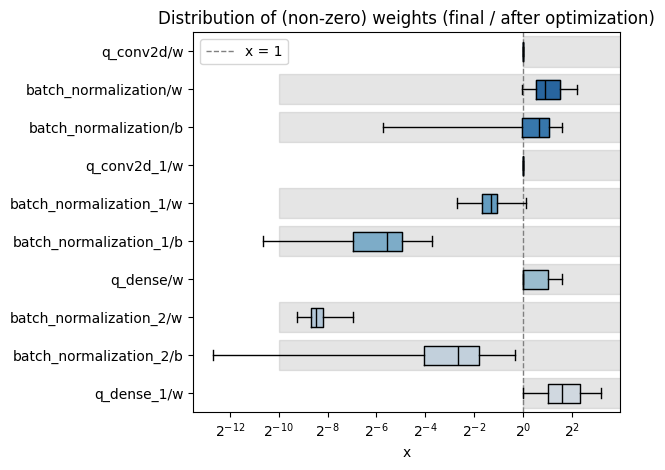

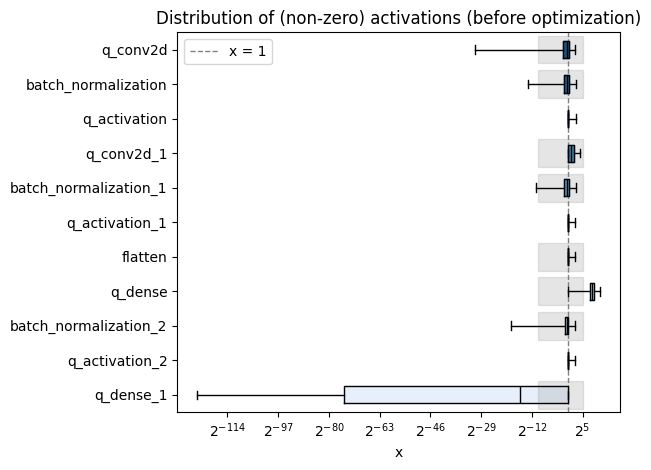

In [14]:
hls_model_teste = hls4ml.converters.convert_from_keras_model(
    q_model,
    output_dir='outputs/t1_teste/8bits',
    backend='Vitis',
    part= 'xc7z020clg400-1',
    clock_period='10',
    project_name='t1_best_8b_teste',
)

hls4ml.model.profiling.numerical(
    model=q_model,
    hls_model=hls_model_teste,
    X=X_test[:1500]
)

Profiling weights (before optimization)
Weights for q_conv2d are only zeros, ignoring.
Weights for q_conv2d_1 are only zeros, ignoring.
Weights for q_dense are only zeros, ignoring.
Weights for q_dense_1 are only zeros, ignoring.
[{'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'q_conv2d', 'weight': 'q_conv2d/w'}, {'med': 1.8787235, 'q1': 1.4411499202251434, 'q3': 2.8512020111083984, 'whislo': 0.95532393, 'whishi': 4.642146, 'layer': 'batch_normalization', 'weight': 'batch_normalization/w'}, {'med': 1.5855598, 'q1': 0.9762490689754486, 'q3': 2.0708855390548706, 'whislo': 0.018895954, 'whishi': 3.0026364, 'layer': 'batch_normalization', 'weight': 'batch_normalization/b'}, {'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'q_conv2d_1', 'weight': 'q_conv2d_1/w'}, {'med': 0.40073115, 'q1': 0.3116987869143486, 'q3': 0.48172924667596817, 'whislo': 0.15345843, 'whishi': 1.0995948, 'layer': 'batch_normalization_1', 'weight': 'batch_normalizatio

(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

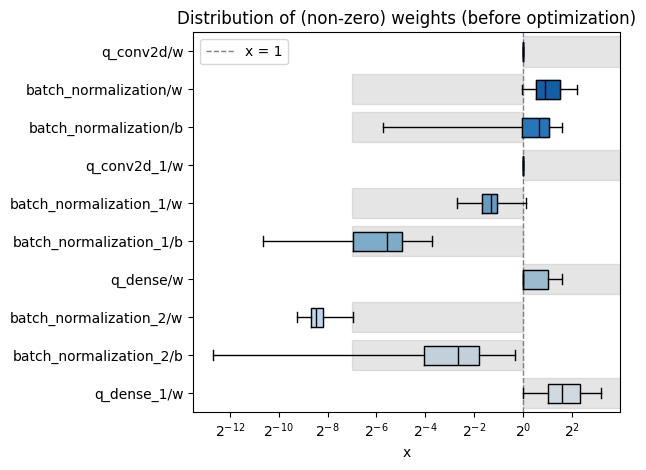

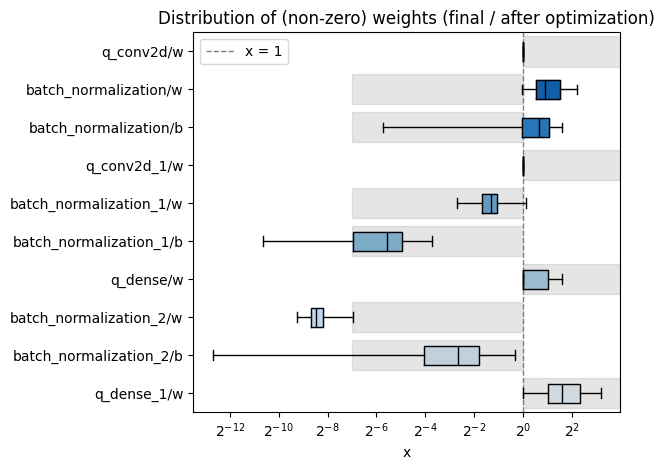

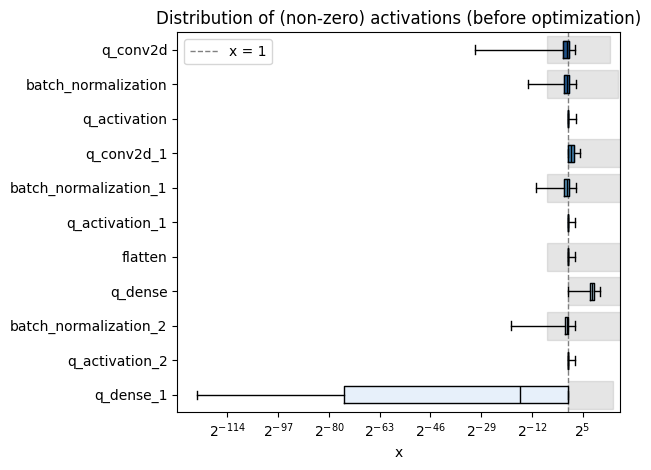

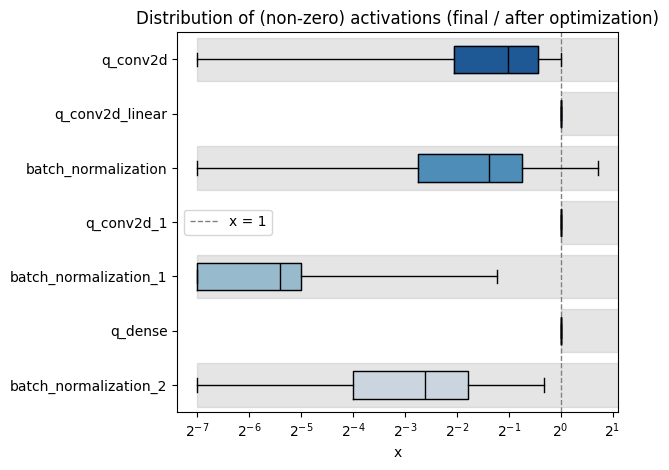

In [ ]:
hls4ml.model.profiling.numerical(
    model=q_model,
    hls_model=hls_model,
    X=X_test[:1500]
)

In [ ]:
#hls_model.write()
hls_model.compile()

In [ ]:
hls_model.build(
        csim=False, #Para testes, estava geerando um erro
        synth=True,
        cosim=False, #Para testes
        export=True,
    )


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Sun Aug 16 13:49:21 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/fauri/Documentos/hls4ml/project/outputs/t1/8bits/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project t1_best_8b_prj 
INFO: [HLS 200-10] Opening project '/home/fauri/Documentos/hls4ml/project/outputs/t1/8bits/t1_best_8b_prj'.
INFO: [HLS 200-1510] Running: set_top t1_best_8b 
INFO: [HLS 200-1510] Running: add_files firmware/t1_best_8b.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/t1_best_8b.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb t1_best_8b_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 't1_best_8b_test.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb firmware/weight

KeyboardInterrupt: 